# Overview
This Jupyter NB is made for exploratory data analysis (EDA) of **HAM10000/ISIC dataset: _"dermatoscopic images from different populations acquired and stored by different modalities"_**

## Sources and References
- **Official name - HAM10000** (Human Against Machine with 10000 training images),

- **Official med source: ISIC archive** https://api.isic-archive.com/collections/212/

- 👉 **Official source with downloadable zip** (used in this NB): https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/DBW86T

- **Official GitHub**: https://github.com/ptschandl/HAM10000_dataset

- **Description by Nature**: https://www.nature.com/articles/sdata2018161

- ❗ **Notes on usage**: https://www.nature.com/articles/sdata2018161#Sec21


## Dataset structure
## Labels
**See also:** info of diagnosis relabeling for HAM10000: https://github.com/ptschandl/HAM10000_dataset/blob/master/unify/unify_diagnoses.ipynb

**Dataset classes/labels (info from dataverse)**:
_"Cases include a representative collection of all important diagnostic categories in the realm of pigmented lesions"_

**First level labels (generated):** 🔴== **malignant** (cancer), 🟢 == **benign** (non-cancer).
[See metadata extension](#adding-new-1st-level-labels-into-csv) method for first level labels generation.

**Second level labels from original metadata**

🔴 **akiec** == Actinic keratoses and intraepithelial carcinoma / Bowen's disease,

🔴 **bcc** == basal cell carcinoma,

🟢 **bkl** == benign keratosis-like lesions (solar lentigines / seborrheic keratoses and lichen-planus like keratoses),

🟢 **df** == dermatofibroma,

🔴 **mel** == melanoma,

🟢 **nv** == melanocytic nevi

🟢 **vasc** == vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage).

## Images and Metadata
**HAM10000 consist of ~10000 dermatoscopic samples**:
1. **Dermatoscopy images** (basically high-res photos, .JPG): dir `HAM10000_images`

     👉❗In Dataverse source, HAM10000 is stored in two parts, `HAM10000_images_part_1` and `HAM10000_images_part_1`, so they were merged into one dir
2. **Binary masks** (segmentations) of the ROI/lesion (.PNG): dir `HAM10000_segmentations_lesion_tschandl`
3. **Metadata** (CSV) in `HAM10000_metadata` file.

    ❗The dataset **[includes lesions with multiple images](#lesion-id-vs-image-id)** ❗, which can be tracked by the `lesion_id` column within the `HAM10000_metadata` file:

    - `lesion_id` - unique lesion ID, e.g. `HAM_0000118`
    - `image_id` - image file ID, e.g. `ISIC_0027419`. ❗Note: `lesion_id` -> `image_id` as "one-to-many"
    - `dx` - diagnosis, e.g. `mel` == melanoma, malignant
    - `dx_type` - diagnosis confirmation type, e.g. `histo` == histopathology
    - `age` - patient's age, rounded like 55-60-65-70-...
    - `sex` - patient's  sex
    - `localization` - lesion localization on the body, e.g. `face`
    - `dataset` - original dataset

**Directory structure for this NB:**

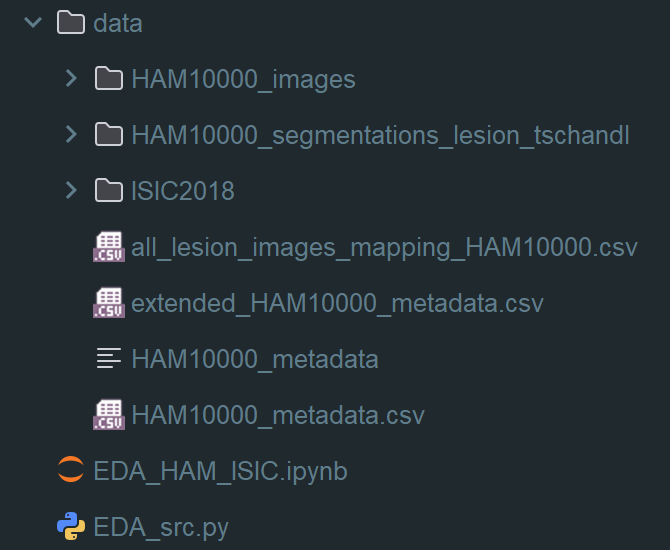

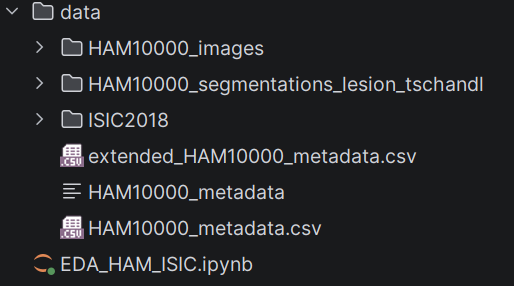
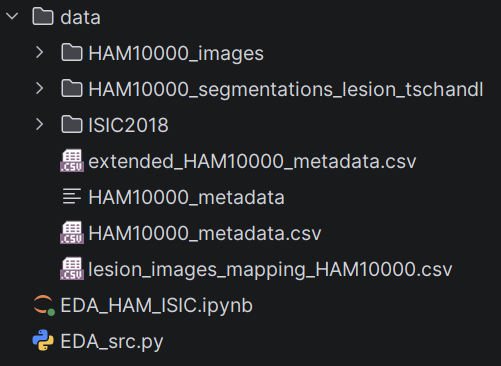
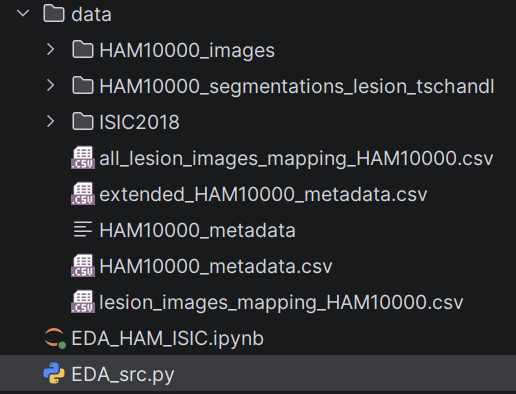
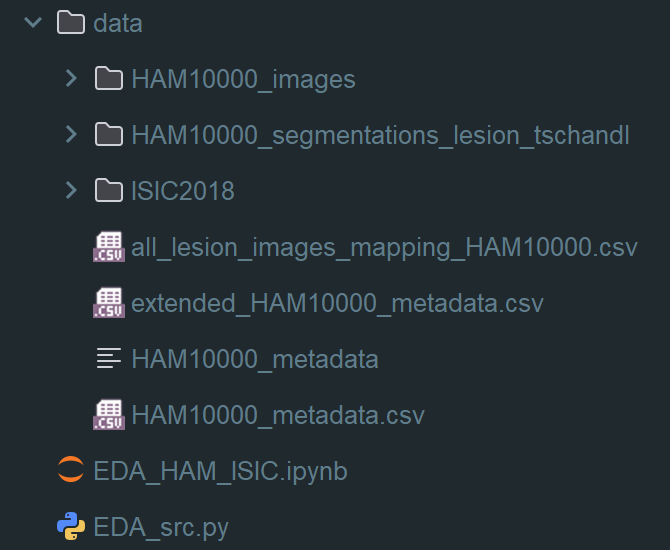

# EDA
## Images samples

In [6]:
import seaborn as sns

from EDA_src import *

print(BASE)

/home/jdem/projects/DataspellProjects/mse-mlops/notebooks/EDA


In [4]:
sample_ds = get_ds(get_sample=True, sample_show=True)

RuntimeError: No (image, mask) matches found.
Sample image: []
Sample mask:  []


## Metadata samples
### Adding new 1st level labels into CSV

In [ ]:
# extending base metadata with new column
metadata_ext()

### Exploring metadata sample

In [ ]:
sample_ds_ids = [img_id for _, _, img_id in sample_ds]
sample_ds_meta = get_metadata(sample_ds_ids)
sample_ds_meta.head()

## Image-CSV mapping on sample


In [ ]:
sample_ds_triplets, sample_ds_meta_df = map_ds_metadata(sample_size=8,
                                                        sample_seed=13,
                                                        get_sample=True,
                                                        sample_show=True)

## Full dataset EDA
### Loading dataset

In [ ]:
full_ds_triplets, full_ds_meta_df = map_ds_metadata()

### Lesion vs Image: one-to-many
Each CSV metadata row contains two IDs:
- `lesion_id` - non-unique value, each lesion may have several images
- `image_id` - unique value

❗See also info on [ID values in metadata](#images-and-metadata)

In [ ]:
lesion_counts, lesion_images = map_lesion_images(full_ds_meta_df, min_img_num=1, verbose=False)

#lesion_counts
#lesion_images

# saving lesion->images into separate CSV
out_df = pd.DataFrame(
    {
        "lesion_id": list(lesion_images.keys()),
        "images": ["{" + ", ".join(imgs) + "}" for imgs in lesion_images.values()],
    }
).sort_values("lesion_id")
out_df.to_csv(MAP_LESION_IMAGES, index=False)
print(f"Result: {len(out_df)} lesions saved into {MAP_LESION_IMAGES}")


In [ ]:
# showing examples of lesion with several pictures
examples_num = 4
candidates = [(lesion_id, imgs) for lesion_id, imgs in lesion_images.items() if len(imgs) == examples_num]
lesion_id, imgs = random.choice(candidates)

_ = get_lesion_info(MAP_LESION_IMAGES, EXT_METADATA, IMG_DIR, lesion_id=lesion_id)


### Example: exploring one lesion

In [ ]:
# Random lesion:
lesion_id, img_ids, meta_rows = get_lesion_info(MAP_LESION_IMAGES, EXT_METADATA, IMG_DIR)

# Specific lesion:
lesion_id, img_ids, meta_rows = get_lesion_info(MAP_LESION_IMAGES, EXT_METADATA, IMG_DIR, lesion_id="HAM_0005496")

### Diagnosis
No missing fields found. See also [info on labels](#labels)

In [ ]:
counts = (
    full_ds_meta_df["dx"]
    .value_counts(dropna=False)
    .sort_index()
)

for dx, n in counts.items():
    dx_str = "NaN" if pd.isna(dx) else str(dx)
    print(f"{n:6d} samples -> dx == {dx_str:<2}, {n / len(full_ds_meta_df) * 100:6.2f}%")

counts = (
    full_ds_meta_df["mb"]
    .value_counts(dropna=False)
    .sort_index()
)

for mb, n in counts.items():
    dx_str = "NaN" if pd.isna(mb) else str(mb)
    print(f"\n{n:6d} samples -> mb == {dx_str:<2}, {n / len(full_ds_meta_df) * 100:6.2f}%")

In [ ]:
# diagnosis labels
palette = {"benign": "green", "malignant": "red"}
ax = sns.countplot(
    data=full_ds_meta_df,
    x="dx",
    hue="mb",
    palette=palette,
    dodge=False,
)
ax.set_xlabel("dx")
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# benign/malignant labels
ax = sns.countplot(
    data=full_ds_meta_df,
    x="mb",
    hue="mb",
    palette=palette,
    dodge=False,
)
ax.set_xlabel("mb")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

### Age
❗️**Missing fields found** ❗

In [ ]:
counts = (
    full_ds_meta_df["age"]
    .value_counts(dropna=False)
    .sort_index()
)

for age, n in counts.items():
    age_str = "NaN" if pd.isna(age) else str(age)
    print(f"{n:6d} samples -> age == {age_str:<2}, {n / len(full_ds_meta_df) * 100:6.2f}%")

ax.set_xlabel("age")
ax.set_ylabel("count")
sns.histplot(full_ds_meta_df["age"])
plt.tight_layout()
plt.grid(axis="x")
ax = sns.countplot()
plt.show()

### Localization
"Unknown" fields found

In [ ]:
counts = (
    full_ds_meta_df["localization"]
    .value_counts(dropna=False)
    .sort_index()
)

for loc, n in counts.items():
    loc_str = "NaN" if pd.isna(loc) else str(loc)
    print(f"{n:6d} samples -> localization == {loc_str:<2}, {n / len(full_ds_meta_df) * 100:6.2f}%")

ax = sns.countplot(data=full_ds_meta_df, x="localization")

# random color per bar (reproducible if you set seed)
random.seed(908)
for p in ax.patches:
    p.set_facecolor((random.random(), random.random(), random.random()))

ax.set_xlabel("localization")
ax.set_ylabel("count")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

### Sex
"Unknown" fields found

In [ ]:
counts = (
    full_ds_meta_df["sex"]
    .value_counts(dropna=False)
    .sort_index()
)

for s, n in counts.items():
    s_str = "NaN" if pd.isna(s) else str(s)
    print(f"{n:6d} samples -> age == {s_str:<2}, {n / len(full_ds_meta_df) * 100:6.2f}%")

ax.set_xlabel("sex")
ax.set_ylabel("count")
sns.histplot(full_ds_meta_df["sex"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis="x")
ax = sns.countplot()
plt.show()